# BIDIRECTIONAL ENCODER REPRESENTATIONS FROM TRANSFORMERS

In the rest of this chapter, we will dive into the pretraining of BERT.

In [1]:
import torch
from torch import nn
from utils import spy

## STEP 1 - Input Representation

In natural language processing, some tasks (e.g., sentiment analysis) take single text as input, while in some other tasks (e.g., natural language inference), the input is a pair of text sequences. The BERT input sequence unambiguously represents both single text and text pairs. In the former, the BERT input sequence is the concatenation of the special classification token “<cls>”, tokens of a text sequence, and the special separation token “<sep>”. In the latter, the BERT input sequence is the concatenation of “<cls>”, tokens of the first text sequence, “<sep>”, tokens of the second text sequence, and “<sep>”. We will consistently distinguish the terminology “BERT input sequence” from other types of “sequences”. For instance, one BERT input sequence may include either one text sequence or two text sequences.

To distinguish text pairs, the learned segment embeddings $e_A$ and $e_B$ are added to the token embeddings of the first sequence and the second sequence, respectively. For single text inputs, only $e_A$ is used.

The following `get_tokens_and_segments` takes either one sentence or two sentences as input, then returns tokens of the BERT input sequence and their corresponding segment IDs.

In [2]:
def get_tokens_and_segments(tokens_a, tokens_b=None):
    """"Get tokens of the BERT input sequence and their segment ID"""
    tokens = ['<cls>'] + tokens_a + ['<sep>']
    # 0 and 1 are marking segment A and B, respectively
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens_b + ['<sep>']
        segments += [1] * (len(tokens_b) + 1)
    return tokens, segments

BERT chooses the Transformer encoder as its bidirectional architecture. Common in the Transformer encoder, positional embeddings are added at every position of the BERT input sequence. However, different from the original Transformer encoder, BERT uses learnable positional embeddings. To sum up, the figure below shows that the embeddings of the BERT input sequence are the sum of the token embeddings, segment embeddings, and positional embeddings.

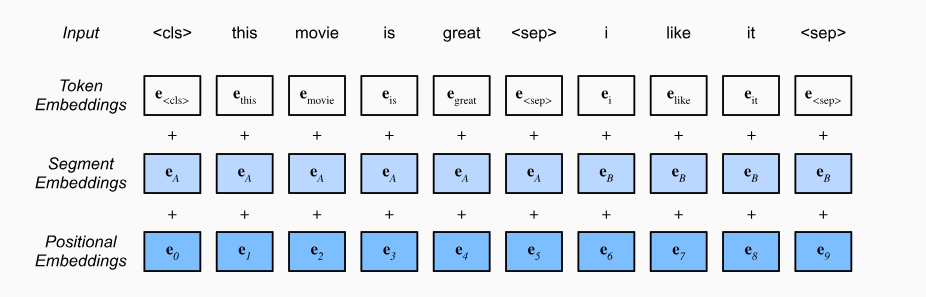

Different from TransformerEncoder, BERTEncoder uses segment embeddings and learnable positional embeddings.

In [3]:
class BERTEncoder(nn.Module):
    """BERT Encoder"""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, dropout, max_len=1000, **kwargs):
        super().__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens)
        # In BERT, positional embedding are learnable
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, num_hiddens))
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", spy.TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, True
            ))

    def forward(self, tokens, segments, valid_lens):
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

Suppose that the vocabulary size is 10000. To demonstrate forward inference of `BERTEncoder`, let’s create an instance of it and initialize its parameters.

In [4]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
ffn_num_input, num_blks, dropout = 768, 2, 0.2
encoder = BERTEncoder(vocab_size, num_hiddens, ffn_num_hiddens, 
                      num_heads, num_blks, dropout)

We define tokens to be 2 BERT input sequences of length 8, where each token is an index of the vocabulary. The forward inference of `BERTEncoder` with the input tokens returns the encoded result where each token is represented by a vector whose length is predefined by the hyperparameter `num_hiddens`. This hyperparameter is usually referred to as the hidden size (number of hidden units) of the Transformer encoder.

In [5]:
tokens = torch.randint(0, vocab_size, (2, 8))
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 768])

## STEP 2 - Pretraining Tasks

The forward inference of `BERTEncoder` gives the BERT representation of each token of the input text and the inserted special tokens `<cls>` and `<seq>`. Next, we will use these representations to compute the loss function for pretraining BERT. The pretraining is composed of the following two tasks: masked language modeling and next sentence prediction.

### 2.1. Masked Language Modeling

A language model predicts a token using the context on its left. To encode context bidirectionally for representing each token, BERT randomly masks tokens and uses tokens from the bidirectional context to predict the masked tokens in a self-supervised fashion. This task is referred to as a masked language model.


In this pretraining task, 15% of tokens will be selected at random as the masked tokens for prediction. To predict a masked token without cheating by using the label, one straightforward approach is to always replace it with a special `<mask>` token in the BERT input sequence. However, the artificial special token `<mask>` will never appear in fine-tuning. To avoid such a mismatch between pretraining and fine-tuning, if a token is masked for prediction (e.g., “great” is selected to be masked and predicted in 'this movie is great'), in the input it will be replaced with:

- A special `<mask>` token for 80% of the time (e.g., 'this movie is great' becomes 'this movie is `<mask>`');

- A random token for 10% of the time (e.g., 'this movie is great' becomes 'this movie is drink');

- The unchanged label token for 10% of the time (e.g., 'this movie is great' becomes 'this movie is great').

Note that for 10% of 15% time a random token is inserted. This occasional noise encourages BERT to be less biased towards the masked token (especially when the label token remains unchanged) in its bidirectional context encoding.


We implement the following `MaskLM` class to predict masked tokens in the masked language model task of BERT pretraining. The prediction uses a one-hidden-layer MLP (`self.mlp`). In forward inference, it takes two inputs: the encoded result of `BERTEncoder` and the token positions for prediction. The output is the prediction results at these positions.

In [7]:
class MaskLM(nn.Module):
    """Masked Language Model implement for BERT"""
    def __init__(self, vocab_size, num_hiddens, **kwargs):
        super().__init__(**kwargs)
        self.mlp = nn.Sequential(
            nn.LazyLinear(num_hiddens),
            nn.ReLU(),
            nn.LayerNorm(num_hiddens),
            nn.LazyLinear(vocab_size)
        )


    def forward(self, X, pred_positions):
        # pred_positions shape: (batch_size, num_pred_positions)
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1)
        batch_size = X.shape[0]
        batch_idx = torch.arange(0, batch_size)
        # Suppose that `batch_size` = 2, `num_pred_positions` = 3, then
        # `batch_idx` is `torch.tensor([0, 0, 0, 1, 1, 1])`
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        # masked_X shape: (batch_size * num_pred_positions, num_hiddens)
        masked_X = X[batch_idx, pred_positions]
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

To demonstrate the forward inference of `MaskLM`, we create its instance `mlm` and initialize it. Recall that `encoded_X` from the forward inference of `BERTEncoder` represents 2 BERT input sequences. We define `mlm_positions` as the 3 indices to predict in either BERT input sequence of `encoded_X`. The forward inference of `mlm` returns prediction results `mlm_Y_hat` at all the masked positions `mlm_positions` of `encoded_X`. For each prediction, the size of the result is equal to the vocabulary size.

In [8]:
mlm = MaskLM(vocab_size, num_hiddens)
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])
mlm_Y_hat = mlm(encoded_X, mlm_positions)
mlm_Y_hat.shape

torch.Size([2, 3, 10000])

With the ground truth labels `mlm_Y` of the predicted tokens `mlm_Y_hat` under masks, we can calculate the cross-entropy loss of the masked language model task in BERT pretraining.

In [9]:
mlm_Y = torch.tensor([[7, 8, 9], [10, 20, 30]])
loss = nn.CrossEntropyLoss(reduction="none")
mlm_l = loss(mlm_Y_hat.reshape((-1, vocab_size)), mlm_Y.reshape(-1))
mlm_l.shape

torch.Size([6])

### 2.2. Next Sequence Prediction

Although masked language modeling is able to encode bidirectional context for representing words, it does not explicitly model the logical relationship between text pairs. To help understand the relationship between two text sequences, BERT considers a binary classification task, next sentence prediction, in its pretraining. When generating sentence pairs for pretraining, for half of the time they are indeed consecutive sentences with the label `True`; while for the other half of the time the second sentence is randomly sampled from the corpus with the label `False`.


The following NextSentencePred class uses a one-hidden-layer MLP to predict whether the second sentence is the next sentence of the first in the BERT input sequence. Due to self-attention in the Transformer encoder, the BERT representation of the special token `<cls>` encodes both the two sentences from the input. Hence, the output layer (`self.output`) of the MLP classifier takes X as input, where X is the output of the MLP hidden layer whose input is the encoded `<cls>` token.

In [11]:
class NextSequencePred(nn.Module):
    """The next sequence prediction task of BERT"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.output = nn.LazyLinear(2)

    
    def forward(self, X):
        # X size: (batch_size, num_hiddens) -> X is <cls> token
        return self.output(X)

We can see that the forward inference of an `NextSentencePred` instance returns binary predictions for each BERT input sequence.

In [12]:
cls_X = encoded_X[:, 0, :]
cls_X = torch.flatten(cls_X, start_dim=1)
nsp = NextSequencePred()
nsp_Y_hat = nsp(cls_X)
nsp_Y_hat.shape

torch.Size([2, 2])

The cross-entropy loss of the 2 binary classifications can also be computed.

In [13]:
nsp_y = torch.tensor([0, 1])
nsp_l = loss(nsp_Y_hat, nsp_y)
nsp_l.shape

torch.Size([2])

## STEP 3 - Putting it all together

When pretraining BERT, the final loss function is a linear combination of both the loss functions for masked language modeling and next sentence prediction. Now we can define the `BERTModel` class by instantiating the three classes `BERTEncoder`, `MaskLM`, and `NextSentencePred`. The forward inference returns the encoded BERT representations `encoded_X`, predictions of masked language modeling `mlm_Y_hat`, and next sentence predictions `nsp_Y_hat`.

In [15]:
class BERTModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout, max_len=1000):
        super().__init__()
        self.encoder = BERTEncoder(vocab_size, num_hiddens, ffn_num_hiddens,
                                   num_heads, num_blks, dropout, max_len)
        self.hidden = nn.Sequential(
            nn.LazyLinear(num_hiddens), 
            nn.Tanh()
            )
        self.mlm = MaskLM(vocab_size, num_hiddens)
        self.nsp = NextSequencePred()


    def forward(self, tokens, segments, valid_lens=None, pred_positions=None):
        encoded_X = self.encoder(tokens, segments, valid_lens)
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat